**Library yang Digunakan**

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.linear_model import LinearRegression

<h2>Pembersihan Data dari Missing Value dan Outliers</h2>
Dataset awal dibaca menggunakan pd.read_csv() dan ditampilkan beberapa baris pertamanya untuk melihat struktur datanya. Missing value kemudian diatasi melalui imputasi, di mana kolom numerik diisi menggunakan median dan kolom kategorikal menggunakan mode. Setelah dipastikan tidak ada lagi missing value, dilakukan pembersihan outlier pada kolom numerik menggunakan metode IQR dengan menghitung Q1, Q3, serta batas bawah dan atas, lalu menghapus baris yang berada di luar rentang tersebut. Setelah proses outlier removal selesai, jumlah baris yang tersisa ditampilkan.

In [6]:
df = pd.read_csv("yield_df.csv")

print("=== DATA AWAL ===")
print(df.head())
print(f"Jumlah Data: {len(df)}")

=== DATA AWAL ===
   Unnamed: 0     Area         Item  Year  hg/ha_yield  \
0           0  Albania        Maize  1990        36613   
1           1  Albania     Potatoes  1990        66667   
2           2  Albania  Rice, paddy  1990        23333   
3           3  Albania      Sorghum  1990        12500   
4           4  Albania     Soybeans  1990         7000   

   average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  
0                         1485.0              121.0     16.37  
1                         1485.0              121.0     16.37  
2                         1485.0              121.0     16.37  
3                         1485.0              121.0     16.37  
4                         1485.0              121.0     16.37  
Jumlah Data: 28242


In [50]:
print(df.dtypes)

Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object


In [8]:
# Metode 1: Menangani Missing Values
for col in df.columns:
    if df[col].dtype == 'float64' or df[col].dtype == 'int64':
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nCek ulang missing values setelah imputasi:")
print(df.isnull().sum())


Cek ulang missing values setelah imputasi:
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


Data ini sudah tidak memiliki missing value.

In [11]:
# Metode 2: Deteksi dan Hapus Outlier (IQR Method)
# Terapkan metode IQR untuk kolom numerik
num_cols = df.select_dtypes(include=[np.number]).columns
print(f"\nData sebelum pembersihan outlier: {df.shape[0]} baris")

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(f"\nData setelah pembersihan outlier: {df.shape[0]} baris")


Data sebelum pembersihan outlier: 28242 baris

Data setelah pembersihan outlier: 24692 baris


<h2>Feature Selection: Mutual Information dan ANOVA</h2> 
Kami menggunakan 2 feature selection yaitu; Mutual Information dan ANOVA. Mutual Information (MI) adalah ukuran statistik yang menyatakan seberapa banyak informasi yang diketahui tentang 1 variabel ketika kita mengetahui variabel lainnya. ANOVA (Analysis Of Variance) adalah metode statistik yang digunakan untuk menguji apakah terdapat perbedaan rata - rata yang signifikan antara 2 atau lebih kelompok.

In [13]:
def select_features_eda(X, y, method='mutual_info'):
    if method == 'mutual_info':
        fs = SelectKBest(score_func=mutual_info_regression, k='all')
    elif method == 'anova':
        fs = SelectKBest(score_func=f_regression, k='all')
    else:
        raise ValueError("method harus 'mutual_info' atau 'anova'")
    
    fs.fit(X, y)
    feat_scores_df = pd.DataFrame({'feature': X.columns})
    
    if method == 'mutual_info':
        feat_scores_df['score'] = fs.scores_
    elif method == 'anova':
        feat_scores_df['F_score'] = fs.scores_
        feat_scores_df['p_value'] = fs.pvalues_
    
    feat_scores_df = feat_scores_df.sort_values(by=feat_scores_df.columns[1], ascending=False).reset_index(drop=True)
    
    return feat_scores_df, fs

In [15]:
# Persiapan Data
X = df.drop(columns=['hg/ha_yield', 'Unnamed: 0'])
y = df['hg/ha_yield']

# Preprocessing
le_area = LabelEncoder()
X['Area'] = le_area.fit_transform(X['Area'])

le_item = LabelEncoder()
X['Item'] = le_item.fit_transform(X['Item'])

# Feature Selection
feat_scores_mi, _ = select_features_eda(X, y, method='mutual_info')
feat_scores_anova, _ = select_features_eda(X, y, method='anova')

print("Mutual Info Scores:")
print(feat_scores_mi)

print("\nANOVA F-scores & p-values:")
print(feat_scores_anova)

Mutual Info Scores:
                         feature     score
0              pesticides_tonnes  2.631011
1                           Area  1.810065
2  average_rain_fall_mm_per_year  1.773278
3                           Year  1.364330
4                           Item  1.203462
5                       avg_temp  0.219734

ANOVA F-scores & p-values:
                         feature     F_score        p_value
0                           Item  659.286307  1.634189e-143
1  average_rain_fall_mm_per_year  126.868455   2.341086e-29
2              pesticides_tonnes  102.081729   5.931108e-24
3                           Year   34.126432   5.229270e-09
4                       avg_temp    3.751941   5.275763e-02
5                           Area    0.028140   8.667824e-01


Feature selection menghasilkan tiga fitur yang paling memempengaruhi hasil panen, yaitu fitur pesticides_tonnes, Item, dan average_rain_fall_mm_per_year

<h2>EDA</h2>
Setelah data dikelola, informasi-informasi penting bisa didapatkan dari data melalui Exploratory Data Analysis untuk melihat tren produksi pertanian, hubungan antara variabel input, dan perbandingan antar negara terhadap penggunaan pestisida dan hasil panen. 

**Analisis bagaimana perkembangan crop yield (hasil panen) dari tahun ke tahun?**

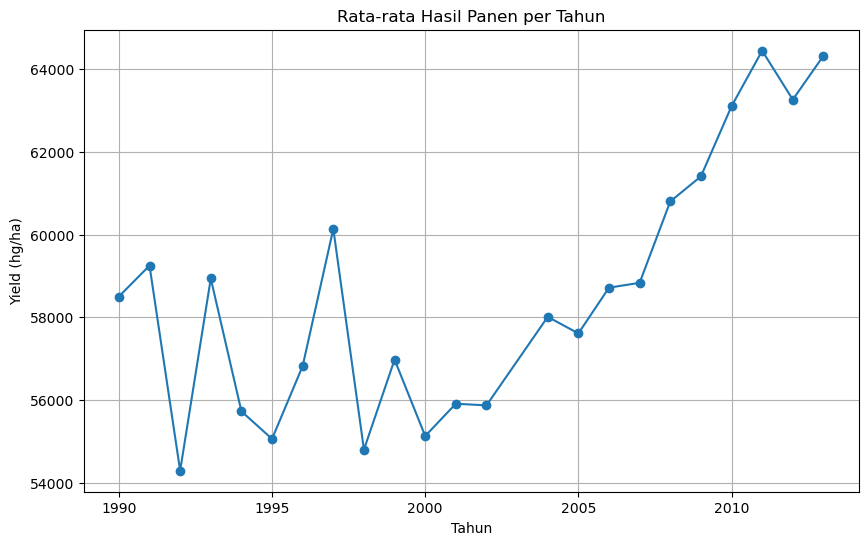

In [69]:
# Membuat Dataframe baru yang berisi kolom Year dan hg/ha_yield
df_xy = pd.DataFrame({
    'Year': X['Year'],
    'yield': y
})

# Mengelompokkan data hg/ha_yield berdasarkan rata-rata per tahun
yield_sum_per_year = df_xy.groupby('Year')['yield'].mean()

# Membuat plot yang memperlihatkan rata-rata hg/ha_yield per tahun
plt.figure(figsize=(10,6))
plt.plot(yield_sum_per_year.index, yield_sum_per_year.values, marker='o')
plt.title('Rata-rata Hasil Panen per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Yield (hg/ha)')
plt.grid(True)
plt.show()


Hasil panen mengalami fluktuasi dari tahun ke tahun. Tahun-tahun sebelum tahun 2000, fluktuasi menunjukkan adanya variasi hasil panen tahunan yang drastis. Sejak tahun 2000-an, terlihat tren kenaikan hasil panen secara bertahap. Perbedaan kedua abad ini mungkin dipengaruhi oleh berbagai faktor, seperti cuaca maupun perkembangan teknologi yang pesat sehingga bisa dilakukan analisa lebih lanjut terhadap faktor-faktor yang mempengaruhi hasil panen. Hasil panen tertinggi terjadi setelah tahun 2010 dengan nilai di atas 62000 hg/ha dan hasil panen terendah tercatat pada tahun antara 1990 - 1995 dengan nilai mendekati 54000 hg/ha. 


**Analisis negara mana yang mengalami kenaikan atau penurunan terbesar?**

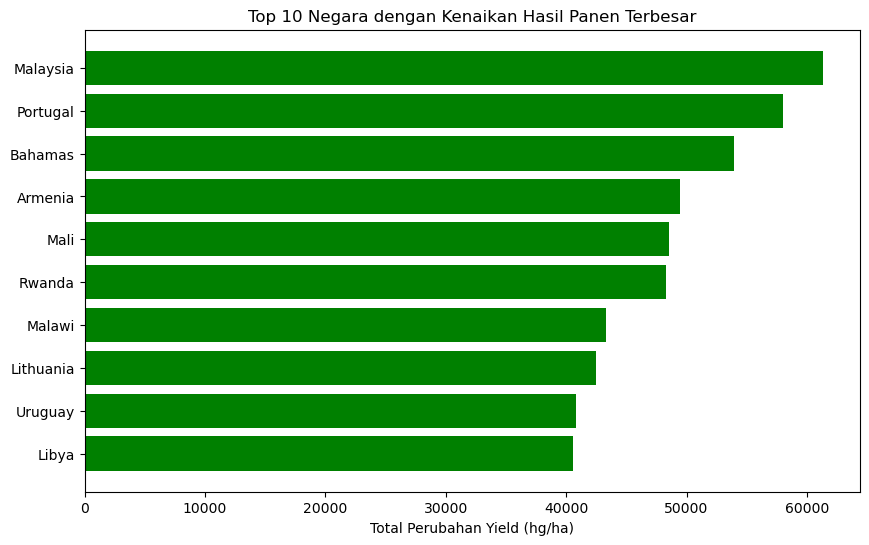

In [15]:
# Membuat dataframe yang berisi rata-rata hg/ha_yield per negara per tahun
df_country_year = (
    df.groupby(['Area', 'Year'])['hg/ha_yield']
    .mean()
    .reset_index()
)

# Menambahkan kolom berisi perubahan hg/ha_yield per tahun untuk setiap negara
df_country_year['yearly_change'] = (
    df_country_year.groupby('Area')['hg/ha_yield'].diff()
)

# Menghitung total kenaikan hg/ha_yield per negara
increase = (
    df_country_year.groupby('Area')['yearly_change']
    .sum()
    .sort_values(ascending=False)
)

# Menghitung total penurunan hg/ha_yield per negara
decrease = (
    df_country_year.groupby('Area')['yearly_change']
    .sum()
    .sort_values()
)

# Mengambil dan plot top 10 negara dengan kenaikan terbesar
top10_inc = increase.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10_inc.index[::-1], top10_inc.values[::-1], color='green')
plt.title("Top 10 Negara dengan Kenaikan Hasil Panen Terbesar")
plt.xlabel("Total Perubahan Yield (hg/ha)")
plt.show()


Dari daftar ini, Malaysia menempati peringkat pertama sebagai negara yang mengalami peningkatan hasil panen paling signifikan sepanjang periode pengamatan. Temuan ini membuka peluang analisis lebih lanjut mengenai faktor-faktor yang mendorong lonjakan produktivitas Malaysia dan bagaimana faktor tersebut berbeda dibandingkan negara lain dalam daftar. Menariknya, Malaysia juga merupakan satu-satunya negara Asia dalam kelompok 10 besar, sementara negara lain didominasi oleh kawasan Barat dan Afrika.

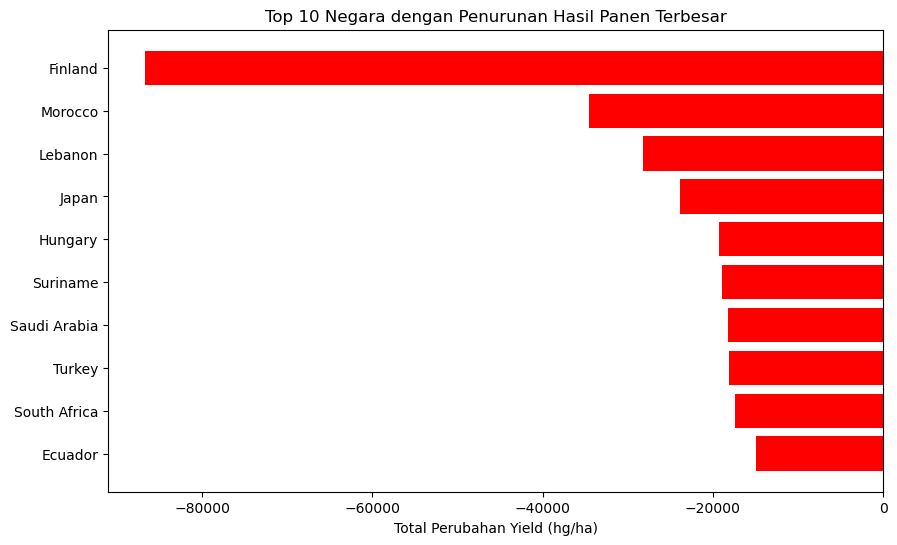

In [17]:
# Mengambil dan plot top 10 negara dengan penurunan terbesar
top10_dec = decrease.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10_dec.index[::-1], top10_dec.values[::-1], color='red')
plt.title("Top 10 Negara dengan Penurunan Hasil Panen Terbesar")
plt.xlabel("Total Perubahan Yield (hg/ha)")
plt.show()

Dari daftar ini, Finland menempati peringkat pertama sebagai negara yang mengalami penurunan hasil panen paling signifikan sebagai periode pengamatan dan jauh lebih rendah dari negara-negara lainnya sehingga membuat Finland menjadi negara outlier.

**Analisis apakah penggunaan pupuk berhubungan dengan peningkatan hasil panen?**

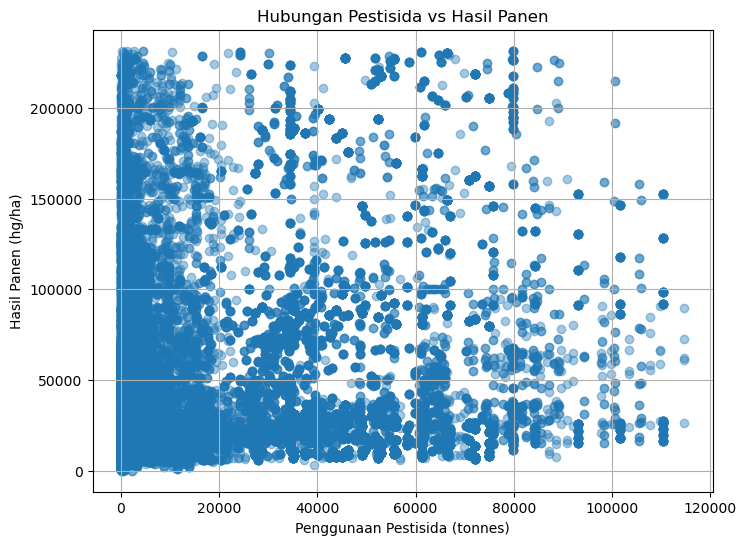

In [19]:
# Plot data untuk menunjukkan apakah ada hubungan antara penggunaan pupuk dan hasil panen
plt.figure(figsize=(8,6))
plt.scatter(df['pesticides_tonnes'], df['hg/ha_yield'], alpha=0.4)
plt.xlabel("Penggunaan Pestisida (tonnes)")
plt.ylabel("Hasil Panen (hg/ha)")
plt.title("Hubungan Pestisida vs Hasil Panen")
plt.grid(True)
plt.show()

Dari sebaran titik pada grafik, titik-titik tersebar acak tanpa arah yang jelas sehingga tidak terbentuk pola garis maupun kecenderungan tertentu. Hal ini menunjukkan bahwa secara visual tidak terdapat hubungan kuat antara besarnya penggunaan pestisida dan tingkat hasil panen.

In [21]:
# Menghitung Korelasi Spearman (data tidak linear)
corr_spear = df['pesticides_tonnes'].corr(df['hg/ha_yield'], method='spearman')
print("Korelasi Spearman =", corr_spear)


Korelasi Spearman = 0.09888710101026375


Hasil ini diperkuat oleh perhitungan korelasi Spearman yang menghasilkan nilai 0.098, yang sangat dekat dengan nol. Nilai tersebut mengindikasikan bahwa hubungan antara kedua variabel bersifat sangat lemah dan tidak signifikan, baik dalam arah positif maupun negatif.

**Analisis apakah penggunaan pestisida tinggi terjadi di negara tertentu saja?**

In [23]:
# Mengelompokkan rata-rata penggunaan pestisida berdasarkan negara
pest_by_country = (
    df.groupby("Area")["pesticides_tonnes"]
    .mean()
    .sort_values(ascending=False)
)

print(pest_by_country.head(10))


Area
France       85238.429565
Italy        80336.703546
Brazil       79985.555000
Japan        70251.011570
Argentina    58621.847843
Colombia     50027.532727
India        48895.184485
Ukraine      46535.490476
Malaysia     43306.311209
Canada       43250.961758
Name: pesticides_tonnes, dtype: float64


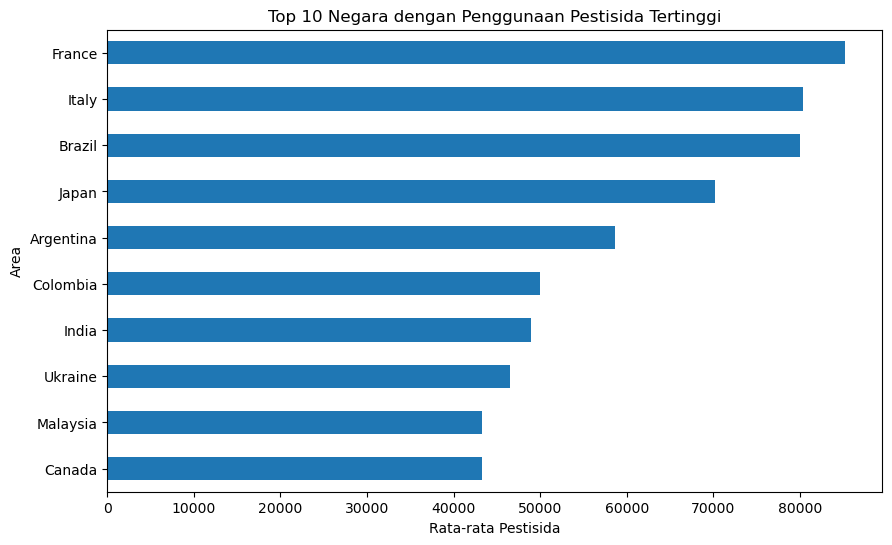

In [25]:
# Menampilkan 10 negara dengan total penggunaan pestisida tertinggi
pest_by_country.head(10).plot(kind='barh', figsize=(10,6))
plt.xlabel("Rata-rata Pestisida")
plt.title("Top 10 Negara dengan Penggunaan Pestisida Tertinggi")
plt.gca().invert_yaxis()
plt.show()


Dari daftar tersebut, France menempati posisi teratas. Menariknya, Malaysia yang sebelumnya tercatat sebagai salah satu negara dengan peningkatan hasil panen terbesar, serta Japan yang termasuk dalam kelompok negara dengan penurunan hasil panen, juga muncul dalam daftar ini sebagai pengguna pestisida yang lebih tinggi dari Malaysia. Temuan ini menegaskan bahwa tingginya penggunaan pestisida tidak secara otomatis berbanding lurus dengan peningkatan hasil panen.

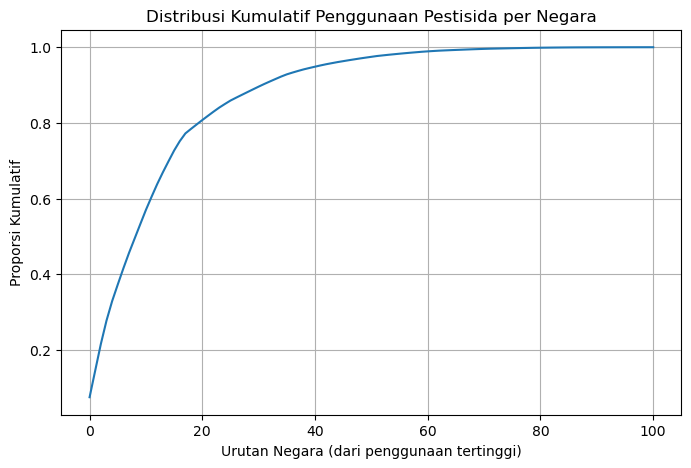

In [27]:
# Menghitung dan memvisualisasikan distribusi kumulatif penggunaan pestisida di seluruh negara
pest_sorted = pest_by_country
pest_cumsum = pest_sorted.cumsum() / pest_sorted.sum()

plt.figure(figsize=(8,5))
plt.plot(pest_cumsum.values)
plt.title("Distribusi Kumulatif Penggunaan Pestisida per Negara")
plt.xlabel("Urutan Negara (dari penggunaan tertinggi)")
plt.ylabel("Proporsi Kumulatif")
plt.grid(True)
plt.show()


Dari grafik tersebut terlihat bahwa sekitar 20 negara teratas menymbang sebagian besar total penggunaan pestisida secara global, dengan jumlah yang jauh lebih tinggi dibandingkan sekitar 80 negara lainnya. Selain itu, terdapat sekitar 40 negara yang hanya menggunakan pestisida dalam jumlah sangat kecil.

**Analisis negara mana yang paling efisien (hasil panen tinggi dengan input rendah)?**

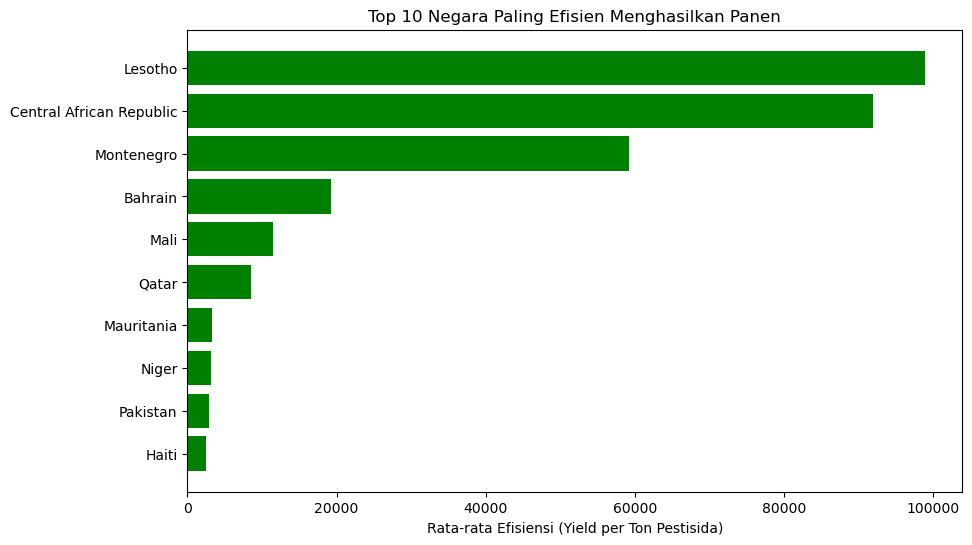

In [62]:
# Menghitung dan memvisualisasikan efisiensi penggunaan pestisida berdasarkan negara
df['efficiency_pesticide'] = df['hg/ha_yield'] / (df['pesticides_tonnes'] + 1e-6)
efficiency_country = (
    df.groupby('Area')['efficiency_pesticide']
    .mean()
    .sort_values(ascending=False)
)

top10_eff = efficiency_country.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10_eff.index[::-1], top10_eff.values[::-1], color='green')
plt.xlabel("Rata-rata Efisiensi (Yield per Ton Pestisida)")
plt.title("Top 10 Negara Paling Efisien Menghasilkan Panen")
plt.show()


Dari grafik terlihat adanya perbedaan signifikan antara tiga negara teratas dengan negara-negara di bawahnya, menunjukkan bahwa Lesotho, Central African Republic, dan Montenegro berhasil mencapai efisiensi penggunaan pestisida yang jauh lebih tinggi dibandingkan negara lain. Negara-negara lain dapat mengambil pelajaran dari strategi dan praktik yang diterapkan di negara-negara paling efisien ini untuk meningkatkan produktivitas tanpa meningkatkan intensitas penggunaan pestisida secara berlebihan.

**Analisis negara mana yang tergantung pada pupuk/pestisida?**

In [60]:
# Menghitung korelasi penggunaan pestisida dan hg/ha_yield untuk setiap negara
countries = df['Area'].unique()
corr_list = []

for c in countries:
    temp = df[df['Area'] == c]
    if temp['pesticides_tonnes'].nunique() > 1:  
        corr = temp['hg/ha_yield'].corr(temp['pesticides_tonnes'])
        corr_list.append({'Area': c, 'corr_yield_pesticide': corr})

corr_df = pd.DataFrame(corr_list).sort_values('corr_yield_pesticide', ascending=False)
print(corr_df.head(10))  


         Area  corr_yield_pesticide
45    Ireland              0.390082
80     Rwanda              0.329060
0     Albania              0.274129
88     Sweden              0.237823
4     Armenia              0.237657
97    Uruguay              0.211407
57     Malawi              0.200552
58   Malaysia              0.180869
51     Latvia              0.172211
55  Lithuania              0.171759


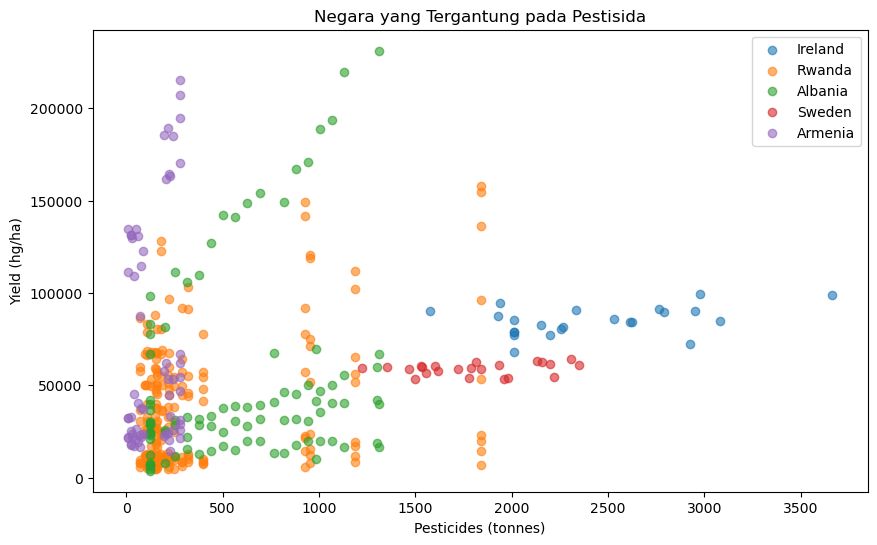

In [37]:
# Memilih dan memvisualisasikan 5 negara dengan korelasi tertinggi
top_countries = corr_df.head(5)['Area'].tolist()

plt.figure(figsize=(10,6))

for c in top_countries:
    temp = df[df['Area'] == c]
    plt.scatter(temp['pesticides_tonnes'], temp['hg/ha_yield'], label=c, alpha=0.6)

plt.xlabel("Pesticides (tonnes)")
plt.ylabel("Yield (hg/ha)")
plt.title("Negara yang Tergantung pada Pestisida")
plt.legend()
plt.show()


Meskipun secara global tidak terdapat korelasi yang kuat antara penggunaan pestisida dan hasil panen, beberapa negara menunjukkan pola yang berbeda. Beberapa negara dari kelima negara di atas memperlihatkan sebaran data yang hampir linear, menunjukkan bahwa perubahan penggunaan pestisida berhubungan cukup konsisten dengan perubahan hasil panen. 

In [58]:
# Menghitung regresi lienar sederhana untuk setiap negara untuk mengukur sensitivitas hasil panen terhadap pestisida
regression_results = []

for c in countries:
    temp = df[df['Area']==c]
    if temp['pesticides_tonnes'].nunique() > 1:
        X = temp[['pesticides_tonnes']].values
        y = temp['hg/ha_yield'].values
        model = LinearRegression().fit(X, y)
        slope = model.coef_[0]
        regression_results.append({'Area': c, 'slope': slope})

reg_df = pd.DataFrame(regression_results).sort_values('slope', ascending=False)
print(reg_df.head(10))


          Area        slope
13    Botswana  1403.669399
66     Namibia  1300.386545
4      Armenia   139.583949
78       Qatar   118.627858
63  Montenegro   115.914717
39       Haiti   102.631323
30     Estonia    70.381694
67       Nepal    43.362866
0      Albania    35.641219
57      Malawi    34.846480


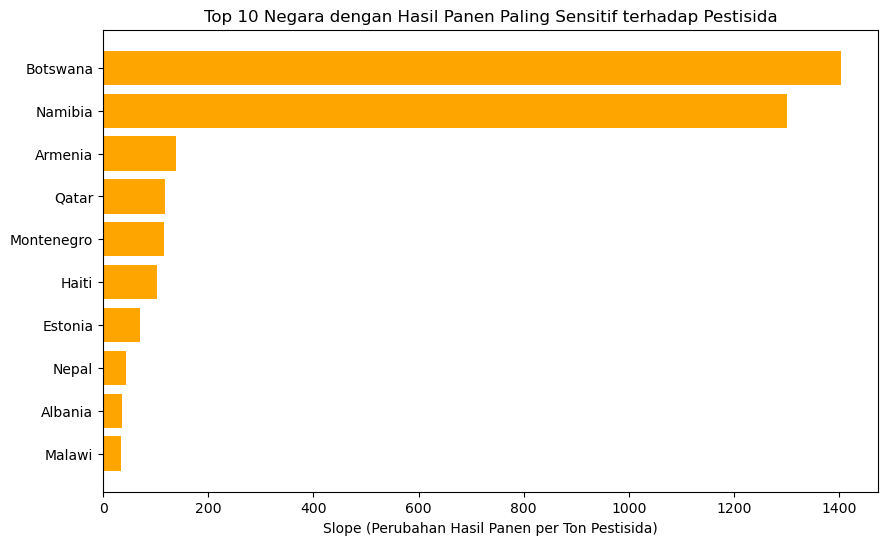

In [45]:
# Memvisualisasikan 10 Negara dengan Hasil Panen Paling Sensitif terhadap Pestisida
top10_slope = reg_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10_slope['Area'][::-1], top10_slope['slope'][::-1], color='orange')
plt.xlabel("Slope (Perubahan Hasil Panen per Ton Pestisida)")
plt.title("Top 10 Negara dengan Hasil Panen Paling Sensitif terhadap Pestisida")
plt.show()

Dari daftar di atas, Botswana memiliki slope tertinggi sebesar 1403,67, diikuti Namibia 1300,39, sedangkan Albania hanya 35,64. Hal ini menunjukkan bahwa di Botswana, setiap tambahan 1 ton pestisida dapat meningkatkan hasil panen sebanyak 1403 hg/ha, sehingga hasil panen sangat sensitif terhadap penggunaan pestisida. Namibia juga sangat sensitif, sedangkan Albania dan negara lain di bawahnya menunjukkan bahwa pestisida hanya memberikan pengaruh kecil terhadap hasil panen.